In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pennylane as qml
import torch
from os.path import join
from os import mkdir

# AWS imports: Import Braket SDK modules
from braket.circuits import Circuit, Gate, Observable
from braket.devices import LocalSimulator
from braket.aws import AwsDevice, AwsQuantumTask
from braket.tracking import Tracker

from scipy.sparse.linalg import expm_multiply
from scipy.sparse import diags, lil_matrix
from utils import *

import sys
sys.path.append('../SimuQ')

In [2]:
from simuq.solver import generate_as
from systems.pde import GenQS
from aais.heis_aais import GenMach
from backends.qiskit_iontrap import transpile

# Task: Inviscid Burgers' equation

Our goal is to simulate the inviscid Burgers' equation:
$$
    \partial_t u + F(u) u\partial_x u = 0,
$$
subject to the initial condition being Gaussian centered at $\mu$ with variance $\sigma^2$:
$$
    u(0,x) = \exp\left(-\frac{1}{2}\left(\frac{x - \mu}{\sigma}\right)^2\right)
$$
and with periodic boundary conditions.

By the level set method, we obtain the *linear* PDE
$$
    \partial_t \phi + p  \partial_{x} \phi = 0,\\
    \phi(0,x,p) = \delta(p - u_0(x)).
$$



In [3]:
N = 10
# m = 10
L = 0
R = 1


h = (R-L)/(N-1)
m = 2
omega = (m * h) #** (1/2)

T = 0.5
N_t = 8
times = np.linspace(0, T, N_t)

x, p = np.meshgrid(np.linspace(L, R, N), np.linspace(L, R, N), indexing='ij')
# X = np.stack([x0_tmp,x1_tmp], axis=-1)

mu = 0.5
sigma = 0.15

u_0 = x #np.exp(-0.5 * ((x - mu) / sigma) ** 2)
phi_0 = delta_1d(p - u_0, omega)
phi_0 /= np.linalg.norm(phi_0)



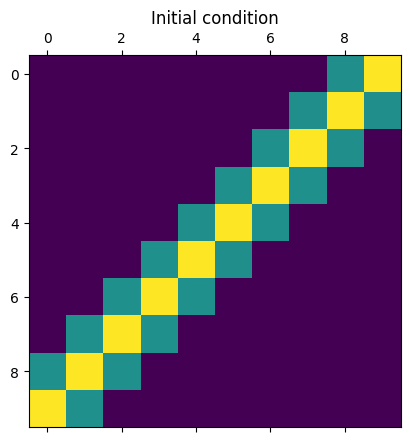

In [5]:
plt.matshow(np.rot90(phi_0))
plt.title("Initial condition")
plt.show()

Train variational circuit to prepare initial state for each chain



In [6]:
encoding = "one-hot"
if encoding == "unary" or encoding == "antiferromagnetic":
    n = N - 1
elif encoding == "one-hot":
    n = N

# number of layers in the circuit
nr_layers = 2

save_dir = join("data", f"burgers_ionq_{nr_layers}")
if not exists(save_dir):
    mkdir(save_dir)

codewords_1d = get_codewords_1d(n, encoding=encoding, periodic=False)


In [7]:
# the kth layer of the circuit ansatz
def layer(params, k):
    # RZ rotations
    # for i in range(n):
    #     qml.RZ(params[i, k, 0], wires=i)
    
    # # XX rotations
    # for i in range(n-1):
    #     qml.IsingXX(params[i, k, 1], wires=[i, i+1])
        
    if k % 2 == 0:
        # RZ rotations
        for i in range(n):
            qml.RZ(params[i, k, 0], wires=i)
            
        # XX rotations
        for i in range(n-1):
            qml.IsingXX(params[i, k, 1], wires=[i, i + 1])

    else:
        # RX rotations
        for i in range(n):
            qml.RX(params[i, k, 0], wires=i)
            
        # ZZ rotations
        for i in range(n-1):
            qml.IsingZZ(params[i, k, 1], wires=[i, i + 1])

In [8]:
dev = qml.device("default.qubit", wires=range(n))
@qml.qnode(dev, interface="torch")
def circuit(params, A):
    n = params.shape[0]

    # repeatedly apply each layer in the circuit
    for j in range(nr_layers):
        layer(params, j)

    # returns the expectation of the input matrix A on the first qubit
    return qml.expval(qml.Hermitian(A, wires=range(n)))

# cost function
def cost_fn(params, M):
    # Put in I - density matrix for target state
    cost = 1 - circuit(params, M)
    return cost

In [59]:
for i in range(N):
    
    print(f"Training for i = {i}")

    # randomly initialize parameters from a normal distribution
    params = np.random.normal(0, np.pi, (n, nr_layers, 2))
    params = torch.tensor(params, requires_grad=True)
    
    target_state = torch.zeros(2 ** n, dtype=torch.complex128)

    for j in range(N):
        target_state[codewords_1d[j]] = phi_0[j,i]

    target_state /= torch.linalg.norm(target_state)

    M = torch.outer(target_state, target_state)

    # set up optimizer
    opt = torch.optim.Adam([params], lr=0.1)

    # number of steps in the optimization routine
    steps = 100

    best_cost = cost_fn(params, M)
    best_params = np.zeros(params.shape)

    print("Cost after 0 steps is {:.4f}".format(cost_fn(params, M)))
    for j in range(steps):
        opt.zero_grad()
        loss = cost_fn(params, M)
        loss.backward()
        opt.step()
        if loss < best_cost:
            best_cost = loss
            best_params = params

        # Keep track of progress every 10 steps
        if j % 10 == 9 or j == steps - 1:
            print(f"Cost after {j+1} steps is {loss:.4f}")


    torch.save(best_params, join(save_dir, f"params_{encoding}_{n}_{i}.pt"))
    

Training for i = 0
Cost after 0 steps is 0.9999
Cost after 10 steps is 0.9390
Cost after 20 steps is 0.2223
Cost after 30 steps is 0.0641
Cost after 40 steps is 0.0259
Cost after 50 steps is 0.0121
Cost after 60 steps is 0.0030
Cost after 70 steps is 0.0015
Cost after 80 steps is 0.0003
Cost after 90 steps is 0.0001
Cost after 100 steps is 0.0001
Training for i = 1
Cost after 0 steps is 0.9981
Cost after 10 steps is 0.7634
Cost after 20 steps is 0.1053
Cost after 30 steps is 0.0782
Cost after 40 steps is 0.0394
Cost after 50 steps is 0.0345
Cost after 60 steps is 0.0304
Cost after 70 steps is 0.0291
Cost after 80 steps is 0.0289
Cost after 90 steps is 0.0287
Cost after 100 steps is 0.0286
Training for i = 2
Cost after 0 steps is 1.0000
Cost after 10 steps is 0.9889
Cost after 20 steps is 0.8850
Cost after 30 steps is 0.1502
Cost after 40 steps is 0.0932
Cost after 50 steps is 0.0518
Cost after 60 steps is 0.0401
Cost after 70 steps is 0.0296
Cost after 80 steps is 0.0294
Cost after 90 

Check the quality of state preparation

In [9]:
use_real_machine = False

if use_real_machine:
    device = AwsDevice("arn:aws:braket:::device/qpu/ionq/ionQdevice")
else:
    # set up device: Local Simulator
    device = LocalSimulator()

print(f"Using {device.name}")

Using StateVectorSimulator


In [10]:
# circuit for state preparation in embedding subspace
# Note that qubit order is reversed for PennyLane!
def state_preparation(params):
    n, nr_layers, _ = params.shape
    
    circuit = Circuit()

    for k in range(nr_layers):
        if k % 2 == 0:
            # RZ rotations
            for i in range(n):
                circuit.rz(n - i - 1, params[i, k, 0])
                
            # XX rotations
            for i in range(0, n-1, 2):
                circuit.xx(n - i - 1, n - i - 2, params[i, k, 1])
            for i in range(1, n-1, 2):
                circuit.xx(n - i - 1, n - i - 2, params[i, k, 1])

        else:
            # RX rotations
            for i in range(n):
                circuit.rx(n - i - 1, params[i, k, 0])
                
            # ZZ rotations
            for i in range(0, n-1, 2):
                circuit.zz(n - i - 1, n - i - 2, params[i, k, 1])
            for i in range(1, n-1, 2):
                circuit.zz(n - i - 1, n - i - 2, params[i, k, 1])

    return circuit

In [11]:
# save_dir = join("data", "gaussian")

sim_dist = np.zeros((N, N))

num_shots = 1000
dimension = 1

for i in range(N):
    params = torch.load(join(save_dir, f"params_{encoding}_{n}_{i}.pt"))
    params = params.detach().numpy()

    circuit = state_preparation(params)

    task = device.run(circuit, shots=num_shots)

    result = task.result()
    occurrences = get_occurrences(N, result.measurements, num_shots=num_shots, dimension=dimension, encoding=encoding)
    # print(occurrences)
    if np.sum(occurrences) > 0:
        sim_dist[:,i] = occurrences / np.sum(occurrences)


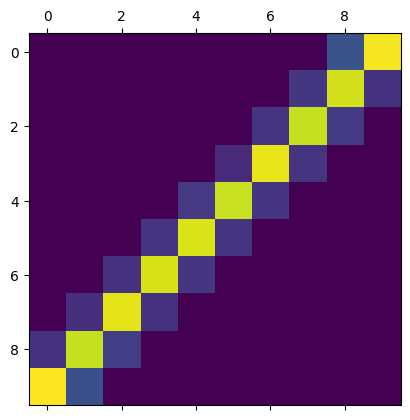

In [12]:
plt.matshow(np.rot90(sim_dist))
plt.show()

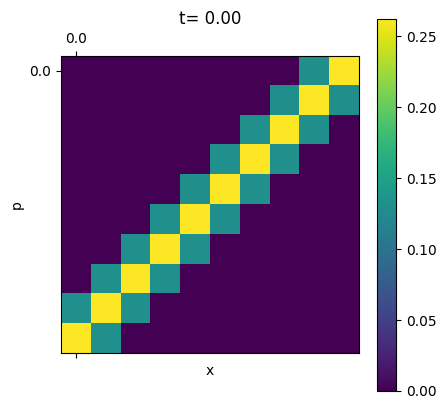

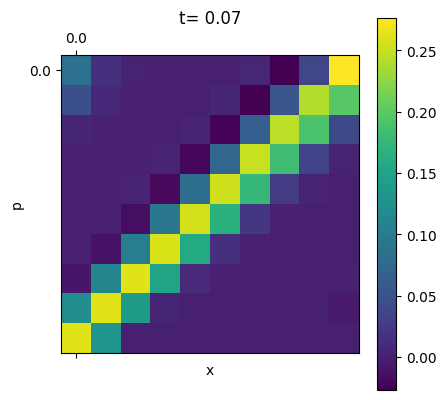

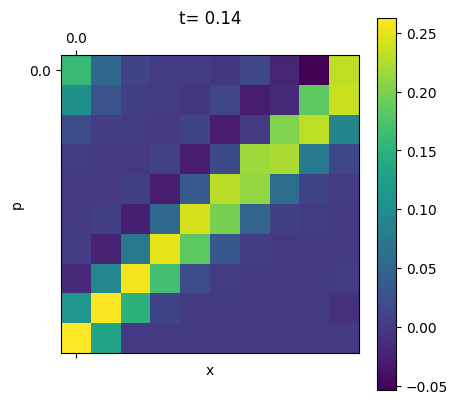

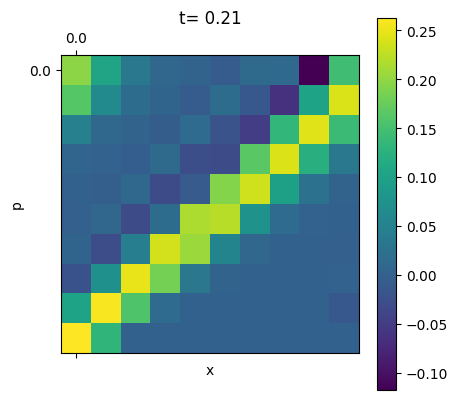

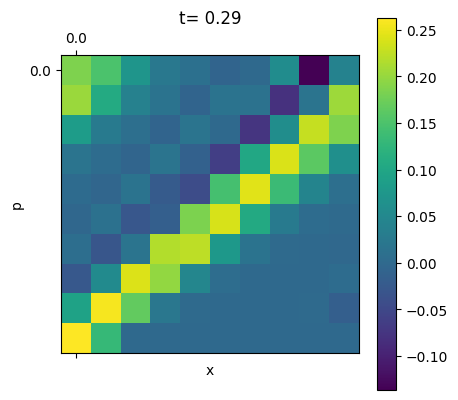

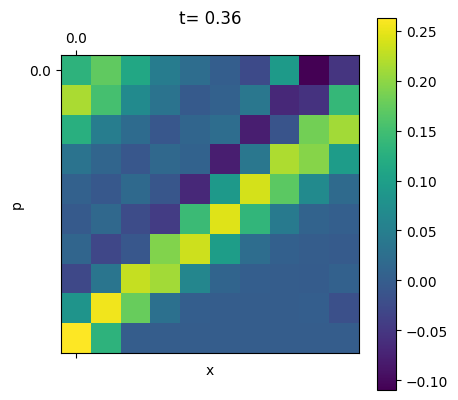

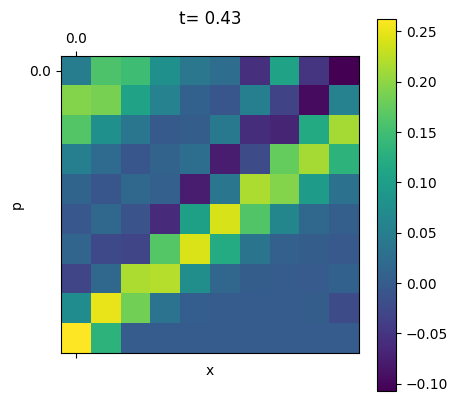

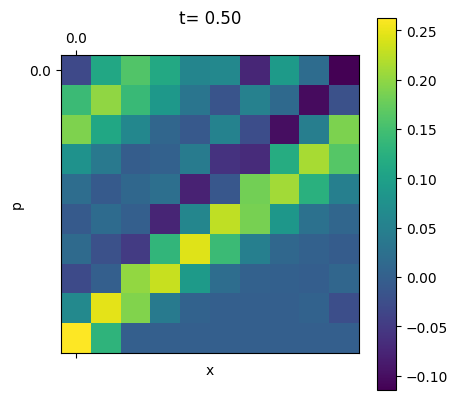

In [13]:
discrete_gradient = diags([-np.ones(N-1), np.zeros(N), np.ones(N-1)], offsets=[-1,0,1])
discrete_gradient = discrete_gradient.tolil()

# periodic boundary conditions
discrete_gradient[0,N-1] = -1
discrete_gradient[N-1,0] = 1

discrete_gradient /= 2 * h

for t in np.linspace(0, T, N_t):
    psi = np.zeros_like(phi_0)
    for i,p_val in enumerate(np.linspace(0, 1, N)):

        # psi[:,i] = ifft(np.exp(-(p_val) * t * evals) * fft(psi_0[:,i])).real
        psi[:,i] = expm_multiply(-p_val * discrete_gradient * t, phi_0[:,i])
    plt.matshow(np.rot90(psi))
    plt.title(f"t={t : 0.2f}")
    plt.xlabel("x")
    plt.xticks(np.arange(N, step=128), np.round(x[::128,0], decimals=2))
    plt.ylabel("p")
    plt.yticks(np.arange(N, step=128), np.round(p[0,::128], decimals=2))
    plt.colorbar()
    # plt.savefig(join(IMG_DIR, f"level_set_{t : 0.2f}.png"), dpi=100, facecolor="white")
    plt.show()

In [14]:
def burgers_circuit(circuit, n, c, T, num_layers, lamb, encoding):
    # n: number of qubits in circuit
    # c: velocity
    # T: evolution time
    # L: number of Trotter layers
    # R: penalty coefficient
    
    if encoding == "unary":
        h = 1 / n
        # print(c)
        for i in range(num_layers):
            # sum of Pauli-y
            circuit.ry(range(n), c * T / (num_layers * h))
        
            # penalty part
            circuit.rz(0, 2 * T * lamb / num_layers)
            circuit.rz(n-1, -2 * T * lamb / num_layers)
            for j in np.arange(0, n-1, 2):
                circuit.zz(j, j+1, - 2 * T * lamb / num_layers)
            for j in np.arange(1, n-1, 2):
                circuit.zz(j, j+1, - 2 * T * lamb / num_layers)
                
    elif encoding == "one-hot":
        h = 1 / (n - 1)
        for i in range(num_layers):

            for j in np.arange(0, n):
                circuit.xy(j, (j+1) % n, c * T / (num_layers * h))
            # XY
            # for j in np.arange(0, n-1, 2):
            #     circuit.xy(j, j+1, c * T / (num_layers * h))
            # for j in np.arange(1, n-1, 2):
            #     circuit.xy(j, j+1, c * T / (num_layers * h))
            # # Periodic boundary conditions
            # circuit.xy(n-1,0, c * T * (num_layers * h))
        
            # penalty part
            circuit.rz(range(n), 2 * T * lamb / num_layers)
            
    return circuit

In [15]:
# save_dir = join("data", "gaussian")

sim_dist = np.zeros((N, N))

num_shots = 1000
dimension = 1
lamb = 4
Trot = 2
tol = 0.5
A = np.zeros((1,1))
T = 0.3

N_t = 10

tv_dist = []

discrete_gradient = diags([-np.ones(N-1), np.zeros(N), np.ones(N-1)], offsets=[-1,0,1])
discrete_gradient = discrete_gradient.tolil()

# periodic boundary conditions
discrete_gradient[0,N-1] = -1
discrete_gradient[N-1,0] = 1

discrete_gradient /= 2 * h


for t in np.linspace(0, T, N_t):
    for i in range(N):
        # Load parameters
        params = torch.load(join(save_dir, f"params_{encoding}_{n}_{i}.pt"))
        params = params.detach().numpy()

        # State preparation part
        circuit = state_preparation(params)

        # # SimuQ
        # circ = None
        # b = np.array([i / (N - 1)])
        # qs = GenQS(N, lamb=lamb, T=T, dimension=dimension, A=A, b=b, L=np.array([L]), R=np.array([R]), encoding=encoding, periodic=True)
        # mach = GenMach(n)

        # _, bk_c = transpile(n, *generate_as(qs, mach, Trot, tol))
        # exec(bk_c)

        # circuit.add_circuit(circ)

        circuit = burgers_circuit(circuit, n, c=i/(N-1), T=t, num_layers=Trot, lamb=lamb, encoding=encoding)
        
        if i == 0 and t == 0:
            print(f"Circuit depth: {circuit.depth}")
        # Run on device
        task = device.run(circuit, shots=num_shots)

        result = task.result()
        occurrences = get_occurrences(N, result.measurements, num_shots=num_shots, dimension=dimension, encoding=encoding)
        # print(occurrences.sum())
        if np.sum(occurrences) > 0:
            sim_dist[:,i] = occurrences / np.sum(occurrences)



    phi = np.zeros_like(phi_0)
    for i,p_val in enumerate(np.linspace(0, 1, N)):

        phi[:,i] = expm_multiply(-p_val * discrete_gradient * t, phi_0[:,i])
        phi[:,i] /= np.linalg.norm(phi[:,i])
        
    ideal_dist = np.abs(phi) ** 2

    # Compute average TV distance
    tv_dist.append(np.average([0.5 * np.sum(np.abs(ideal_dist[:,i] - sim_dist[:,i])) for i in range(N)]))


Circuit depth: 28


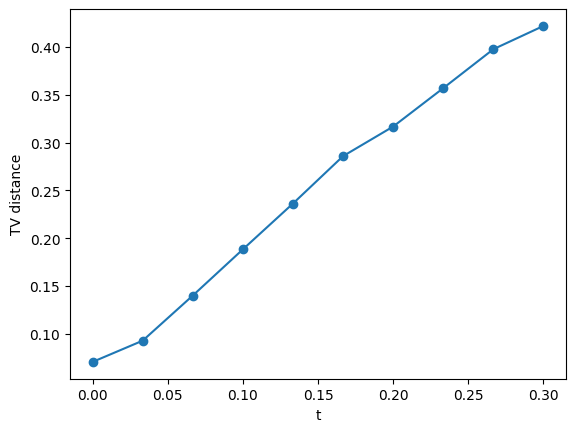

In [17]:
plt.plot(np.linspace(0, T, N_t), tv_dist, 'o-')
plt.xlabel("t")
plt.ylabel("TV distance")
plt.show()

In [16]:
# plt.matshow(np.rot90(ideal_dist))
# plt.colorbar()
# plt.show()
# plt.matshow(np.rot90(sim_dist))
# plt.colorbar()
# plt.show()

# test SimuQ

In [9]:
N = 8
# m = 10
L, R = 0, 1


h = (R-L)/(N-1)
m = 2
omega = (m * h) #** (1/2)

T = 0.1
N_t = 8
times = np.linspace(0, T, N_t)

# x, p = np.meshgrid(np.linspace(L, R, N), np.linspace(L, R, N), indexing='ij')
# # X = np.stack([x0_tmp,x1_tmp], axis=-1)

# mu = 0.5
# sigma = 0.15

# u_0 = x #np.exp(-0.5 * ((x - mu) / sigma) ** 2)
# phi_0 = delta_1d(p - u_0, omega)
# phi_0 /= np.linalg.norm(phi_0)


# SimuQ
encoding = "one-hot"
n = N
Trot = 1
tol = 0.5
circ = None
dimension=1
lamb = 1
A = np.zeros((dimension, dimension))
b = np.ones(dimension)
qs = GenQS(N, lamb=lamb, T=T, dimension=dimension, A=A, b=b, L=np.array([L]), R=np.array([R]), encoding=encoding, periodic=True)
mach = GenMach(n)

_, bk_c = transpile(n, *generate_as(qs, mach, Trot, tol))
exec(bk_c)

Exception: No solution is found.